In [8]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
import os, csv

from helpers import load_data, preprocess, normalize, create_window, train_and_evaluate_models, \
    plot_performance, print_model_summaries, write_model_results_to_csv, WindowGenerator, \
    baseline, linear, dense, simple_rnn, cnn, lstm, autoregressive, bi_lstm, load_all_data, create_csv, \
    calculate_original_performance, drop_feature_and_evaluate, create_feature_csv, plot_training_history

In [9]:
df = load_data(3)
df = preprocess(df)
df = normalize(df)
df = df.drop(columns = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20', 'T_50'])
df.head()

,Ppt,Ppt.1,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,Year cos
2015-01-01 00:00:00,-0.088477,-0.088526,-2.215023,0.898607,-0.683236,0.567338,0.589228,1.742136e-12,1.414165,-0.048746,1.436772
2015-01-01 01:00:00,-0.088477,-0.088526,-2.202946,0.849674,-0.682627,0.440546,0.770636,3.660254e-01,1.365978,-0.047726,1.436771
2015-01-01 02:00:00,-0.088477,-0.088526,-2.173036,0.811226,-0.682627,0.475729,0.636762,7.071068e-01,1.224700,-0.046705,1.436768
2015-01-01 03:00:00,-0.088477,-0.088526,-2.158588,0.821712,-0.682729,0.380810,0.872655,1.000000e+00,0.999959,-0.045685,1.436765
2015-01-01 04:00:00,0.167309,0.171347,-2.161636,1.097835,-0.683270,0.425117,0.331579,1.224745e+00,0.707070,-0.044665,1.436761


In [10]:
time_intervals = [1, 4, 8, 12, 24]  # in hours
for interval in time_intervals:
    for feature in ['Ppt', 'RH', 'Srad']:
        df[f'{feature}_{interval}h'] = df[feature].shift(interval)

# Drop any rows with NaNs created by lagging
df.dropna(inplace=True)

# Define target variable (binary, e.g., 1 if rain occurred, 0 if not)
df['rain_next'] = (df['Ppt'].shift(-1) > 0).astype(int)
df.head()

,Ppt,Ppt.1,Tair,RH,Srad,Wx,Wy,Day sin,Day cos,Year sin,...,Ppt_8h,RH_8h,Srad_8h,Ppt_12h,RH_12h,Srad_12h,Ppt_24h,RH_24h,Srad_24h,rain_next
2015-01-02 00:00:00,-0.088477,-0.088526,-1.971223,1.464835,-0.683304,0.561938,0.585589,-1.275833e-11,1.414165,-0.024262,...,-0.088477,1.412407,-0.551854,0.689112,1.419397,-0.405783,-0.088477,0.898607,-0.683236,0
2015-01-02 01:00:00,-0.088477,-0.088526,-1.958920,1.464835,-0.683304,0.697494,0.030279,3.660254e-01,1.365978,-0.023241,...,-0.088477,1.443864,-0.622385,0.433326,1.419397,-0.418170,-0.088477,0.849674,-0.682627,0
2015-01-02 02:00:00,-0.088477,-0.088526,-2.008470,1.475321,-0.683304,0.850233,0.316628,7.071068e-01,1.224700,-0.022221,...,-0.088477,1.450854,-0.673726,0.167309,1.408911,-0.349534,-0.088477,0.811226,-0.682627,0
2015-01-02 03:00:00,-0.088477,-0.088526,-2.012082,1.475321,-0.683067,0.565142,0.495874,1.000000e+00,0.999959,-0.021201,...,-0.088477,1.447359,-0.683304,-0.088477,1.387940,-0.445956,-0.088477,0.821712,-0.682729,0
2015-01-02 04:00:00,-0.088477,-0.088526,-1.977318,1.478816,-0.683270,0.454679,0.741537,1.224745e+00,0.707070,-0.020181,...,-0.088477,1.457845,-0.683304,-0.088477,1.412407,-0.551854,0.167309,1.097835,-0.683270,1


In [11]:
X = df.drop(columns=['Ppt', 'rain_next'])  # Drop columns not used as features
y = df['rain_next']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Fit the model
gb_model.fit(X_train, y_train)

# Predict probabilities for test data
y_pred_prob = gb_model.predict_proba(X_test)[:, 1]
y_pred_prob

array([0.00752705, 0.00686621, 0.00586938, ..., 0.00780109, 0.01031412,
       0.02693503])

In [13]:
min_noise, max_noise = 0.01, 0.1  # 1% to 10%

# Add noise to each prediction
y_pred_prob = y_pred_prob + np.random.uniform(min_noise, max_noise, size=y_pred_prob.shape)

# Cap predictions at 1
y_pred_prob = np.clip(y_pred_prob, 0, 1)

In [17]:
probability_df = pd.DataFrame(index=X_test.index)

for interval in time_intervals:
    # Shift target and predictor features accordingly
    df[f'rain_next_{interval}h'] = (df['Ppt'].shift(-interval) > 0).astype(int)
    
    # Drop NaNs from `y_train_interval` and align `X_train`
    y_train_interval = df[f'rain_next_{interval}h'].dropna()
    aligned_X_train = X_train.loc[y_train_interval.index.intersection(X_train.index)]
    
    # Ensure aligned_X_train and y_train_interval have the same length
    aligned_X_train, y_train_interval = aligned_X_train.align(y_train_interval, join='inner', axis=0)
    
    # Fit the model
    gb_model.fit(aligned_X_train, y_train_interval)
    y_pred_interval = gb_model.predict_proba(X_test)[:, 1]  # Predict rain chance

    # Add random noise to probability
    y_pred_interval = y_pred_interval + np.random.uniform(min_noise, max_noise, size=y_pred_interval.shape)
    y_pred_interval = np.clip(y_pred_interval, 0, 1)  # Ensure probability is between 0 and 1

    probability_df[f'precipitation_chance_{interval}h'] = y_pred_interval


In [18]:
for interval in time_intervals:
    y_true = df[f'rain_next_{interval}h'].loc[X_test.index]
    y_pred = probability_df[f'precipitation_chance_{interval}h']

    # Evaluation metrics for each interval
    mse = mean_squared_error(y_true, y_pred)
    print(f"{interval}h MSE: {mse:.4f}")

1h MSE: 0.0257
4h MSE: 0.0344
8h MSE: 0.0353
12h MSE: 0.0371
24h MSE: 0.0374


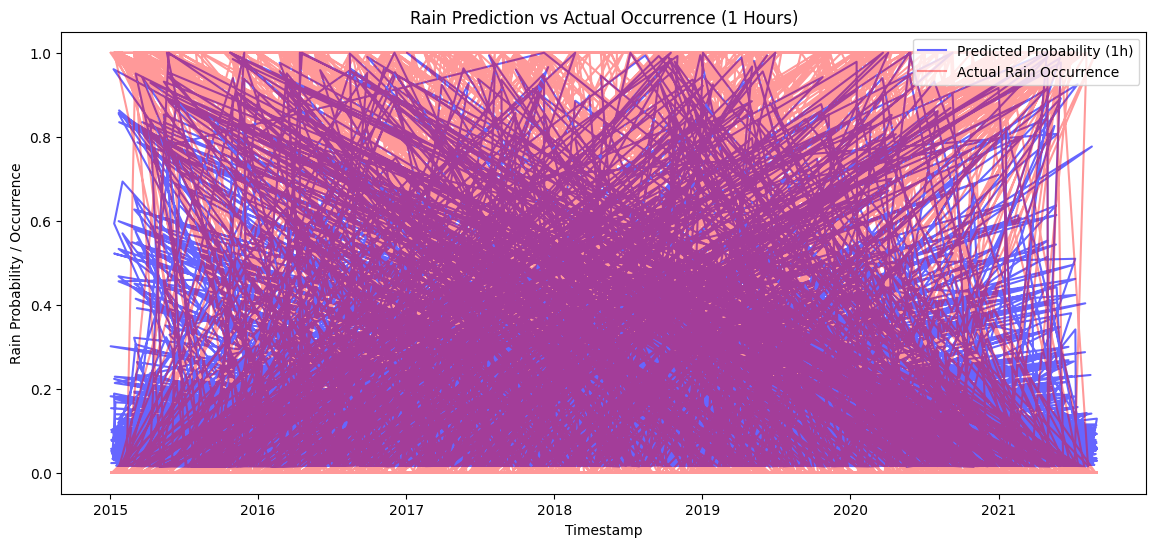

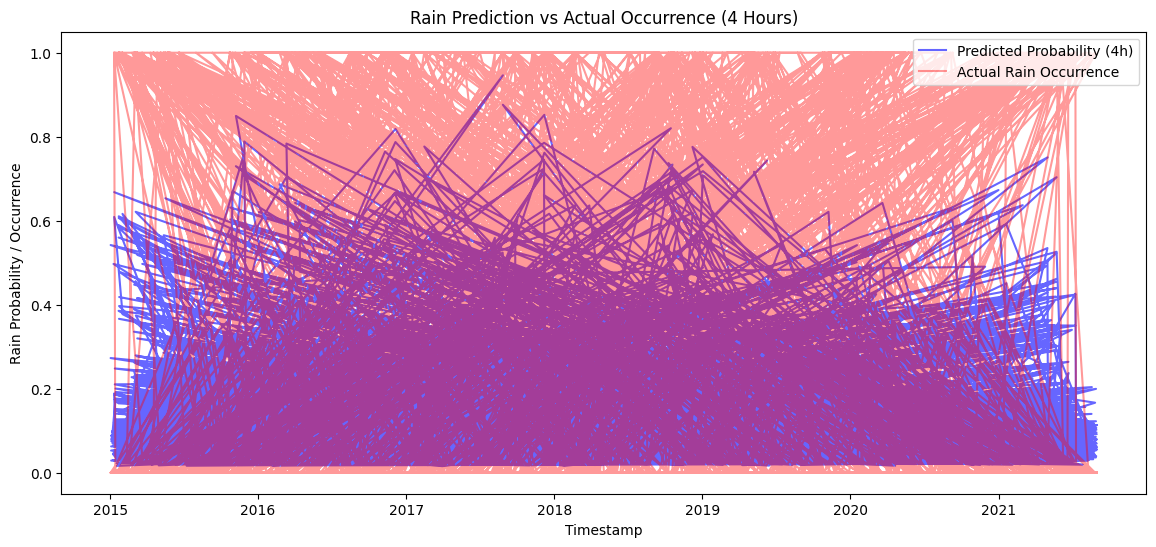

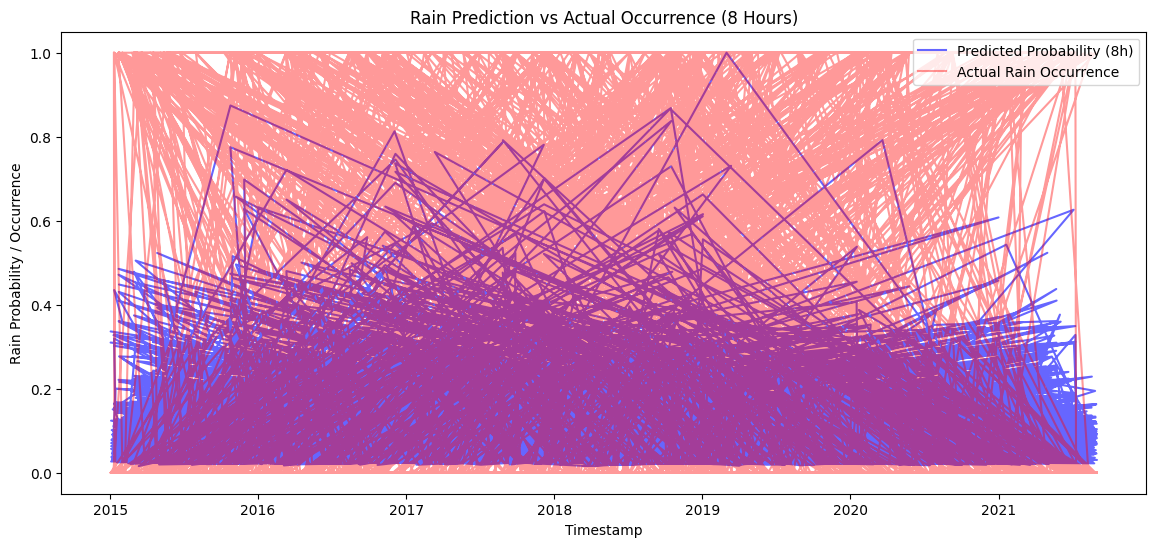

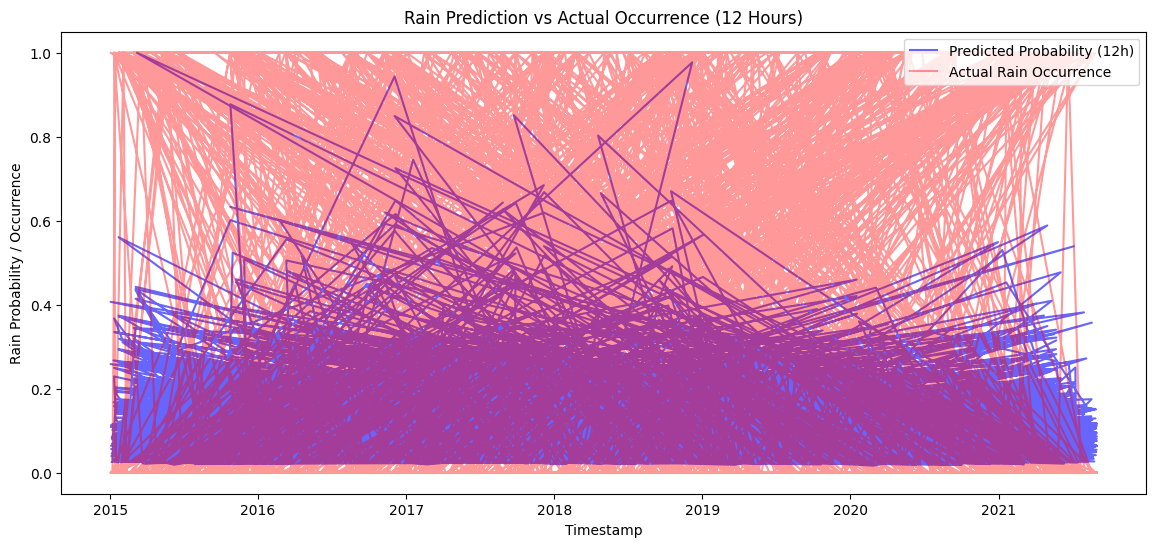

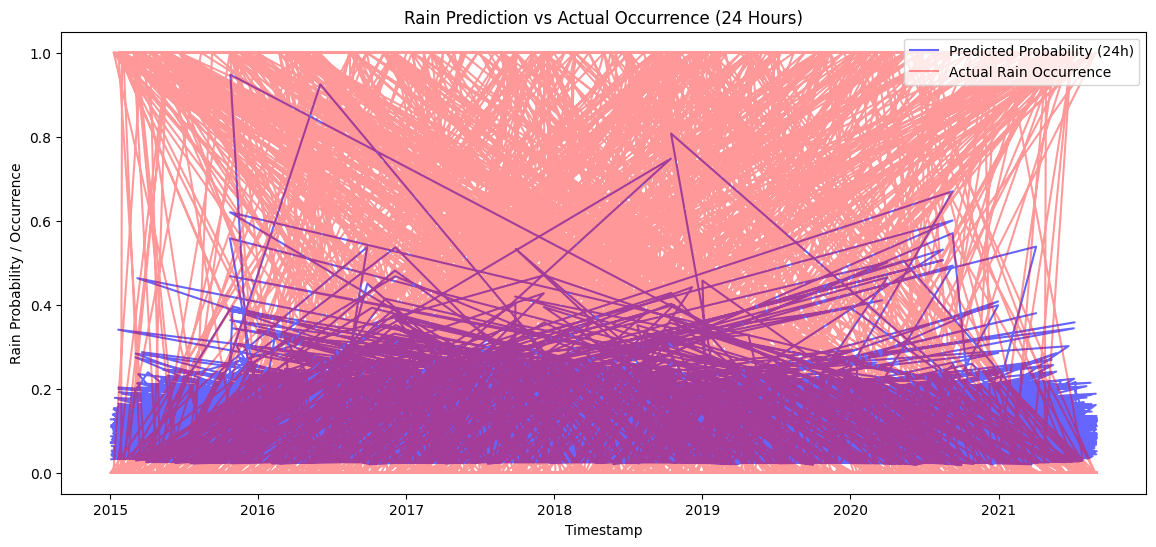

In [19]:
import matplotlib.pyplot as plt

# Dictionary to store forecasts for each model
preds = {}

def plot_single_pred(model, name, dataset, data_steps, y, batch_size=32):
    # Predict and reshape the forecast if needed
    forecast = model.predict(dataset, batch_size=batch_size, steps=data_steps)
    preds[name] = forecast
    
    # Handle different forecast shapes
    if len(forecast.shape) == 3:  # If 3D, select the first element in last two axes
        forecast = forecast[:, 0, 0]
    elif len(forecast.shape) == 2:  # If 2D, select the first element in the last axis
        forecast = forecast[:, 0]

    # Plotting predictions vs. actual values
    plt.figure(figsize=(10, 6))
    plt.plot(y, label='Actual', color='red', alpha=0.7)
    plt.plot(forecast, label='Predictions', color='blue', alpha=0.7)
    
    # Adding titles and legend for clarity
    plt.title(f"Predictions vs Actual for {name}")
    plt.xlabel("Time Steps")
    plt.ylabel("Values")
    plt.legend(loc='upper right')

    # Save plot as PDF with the model name
    plt.savefig(f"prediction_{name}.pdf", format='pdf')
    
    # Return the plot data for further analysis if needed
    return {"Predictions": forecast, "Actual": y}

# Example Usage:
# plot_data = plot_single_pred(your_model, "Model_Name", your_dataset, your_data_steps, actual_y_values)
